# Network Biology Analysis: From Gene Expression to Protein Networks

**Dataset:** Lung Cancer vs Healthy Tissue (TCGA)  
**Learning Objectives:**
- Explore differential gene expression data
- Build and analyze protein-protein interaction networks
- Apply network clustering algorithms
- Understand biological data through a computational lens

## Background

**What is gene expression data?**  
Think of genes as "recipes" in our DNA. Gene expression tells us how actively each recipe is being used. In disease states like cancer, certain genes become much more or less active than normal.

**What are protein-protein interactions?**  
When genes are expressed, they are transcribed and translated into proteins. Proteins are the molecular machines that do most of the work in cells. They often work together by physically interacting, forming complex networks. Understanding these networks helps us identify:
- Key "hub" proteins that interact with many others
- Functional modules (clusters of proteins working together)
- Potential drug targets

## Set up
Work together and discuss with each other!
- 🟢 **Code**: Code provided - run and observe
- 🟡 **TODO**: You need to complete these - look for TODO comments
- ❓ **Question**: Analysis questions you need to answer


In [6]:
# 🟢 Install required packages (run this cell first)
!pip install py4cytoscape pandas numpy matplotlib seaborn networkx requests plotly scikit-learn python-louvain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import requests
import json
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import py4cytoscape as p4c
from py4cytoscape import *

import logging
logging.getLogger().setLevel(logging.ERROR)
logging.disable(logging.DEBUG)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("All packages imported successfully!")

All packages imported successfully!


'pip' is not recognized as an internal or external command,
operable program or batch file.


## Dataset

In this script, we will explore the differential gene expression dataset comparing lung cancer vs. healthy tissue samples. The RNA-sequencing dataset was retrieved from TCGA (The Cancer Genome Atlas) and already pre-processed.

In [7]:
# 🟢 Load the lung cancer dataset
# The Excel file 'lung-cancer-data.xlsx' is available on Canvas
data = pd.read_excel('C:\\Users\\apicv\\Projects\\MSMBS-Group-1\\lung-cancer-data.xlsx')

print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Dataset shape: (36841, 5)
Columns: ['GeneID', 'GeneName', 'log2FC', 'P.Value', 'adj.P.Value']


,GeneID,GeneName,log2FC,P.Value,adj.P.Value
0,ENSG00000000003,TSPAN6,1.210920,0.030286,0.201039
1,ENSG00000000005,TNMD,1.601534,0.171398,0.444140
2,ENSG00000000419,DPM1,0.467465,0.294138,0.564899
3,ENSG00000000457,SCYL3,0.054446,0.891635,1.000000
4,ENSG00000000460,C1orf112,1.437689,0.004173,0.100585


## Step 1: Data Exploration

Let's understand what we're working with. This dataset contains gene expression measurements comparing lung cancer tissue to healthy tissue.

**Key columns to understand:**
- `log2FC`: Log2 fold change (how much gene expression changed)
- `adj.P.Value`: Statistical significance of the change
- `GeneName`: Human-readable gene name
- `GeneID`: Unique gene identifier

In [8]:
# 🟢 Explore the dataset structure
print("=== DATASET OVERVIEW ===")
print(f"Number of genes (rows): {data.shape[0]}")
print(f"Number of features (columns): {data.shape[1]}")
print(f"\nColumns: {list(data.columns)}")

print("\n=== SAMPLE OF DATA ===")
display(data.head(10))

print("\n=== DATA TYPES ===")
print(data.dtypes)

print("\n=== SUMMARY STATISTICS ===")
display(data.describe())

=== DATASET OVERVIEW ===
Number of genes (rows): 36841
Number of features (columns): 5

Columns: ['GeneID', 'GeneName', 'log2FC', 'P.Value', 'adj.P.Value']

=== SAMPLE OF DATA ===


,GeneID,GeneName,log2FC,P.Value,adj.P.Value
0,ENSG00000000003,TSPAN6,1.210920,0.030286,0.201039
1,ENSG00000000005,TNMD,1.601534,0.171398,0.444140
2,ENSG00000000419,DPM1,0.467465,0.294138,0.564899
3,ENSG00000000457,SCYL3,0.054446,0.891635,1.000000
4,ENSG00000000460,C1orf112,1.437689,0.004173,0.100585
5,ENSG00000000938,FGR,-2.995943,0.000005,0.005028
6,ENSG00000000971,CFH,-0.254214,0.609656,0.920902
7,ENSG00000001036,FUCA2,-0.069719,0.881439,1.000000
8,ENSG00000001084,GCLC,1.779400,0.001232,0.057757
9,ENSG00000001167,NFYA,0.492829,0.136904,0.380303



=== DATA TYPES ===
GeneID          object
GeneName        object
log2FC         float64
P.Value        float64
adj.P.Value    float64
dtype: object

=== SUMMARY STATISTICS ===


,log2FC,P.Value,adj.P.Value
count,36841.000000,3.684100e+04,36841.000000
mean,0.738827,3.989555e-01,0.584811
std,1.777936,3.645953e-01,0.339211
min,-8.742461,3.580000e-08,0.000853
25%,-0.139992,6.126199e-02,0.262812
50%,0.268365,2.912378e-01,0.560967
75%,1.476641,7.396475e-01,1.000000
max,13.717148,1.000000e+00,1.000000


❓ **Question**: Dataset Structure
Examine the dataset structure.
* How many rows and columns does it have?
    - 3 rows, 8 columns
* What do the rows and columns represent?
    - column gene characteristics, row each gene.
---

### Identifying Differentially Expressed Genes (DEGs)

Think of this as a classification problem where we're identifying which features (genes) are significantly different between two conditions. We use statistical thresholds similar to how you might filter important features in ML.

In [13]:
# 🟢 Set thresholds for identifying significant changes
log2fc_cutoff = 1  # Genes must change by at least 2-fold (2^1 = 2)
pvalue_cutoff = 0.05  # 5% false discovery rate

# Filter for differentially expressed genes
degs = data[(abs(data['log2FC']) > log2fc_cutoff) & (data['adj.P.Value'] < pvalue_cutoff)]

print(f"Total genes in dataset: {len(data)}")
print(f"Significantly changed genes (DEGs): {len(degs)}")
print(f"Percentage of genes that changed: {len(degs)/len(data)*100:.1f}%")
print(f"\nCutoff values used:")
print(f"- Log2 fold change: ±{log2fc_cutoff} (= ±{2**log2fc_cutoff:.1f}-fold change)")
print(f"- Adjusted p-value: <{pvalue_cutoff}")

Total genes in dataset: 36841
Significantly changed genes (DEGs): 1024
Percentage of genes that changed: 2.8%

Cutoff values used:
- Log2 fold change: ±1 (= ±2.0-fold change)
- Adjusted p-value: <0.05


❓ **Question**: Differential Expression Thresholds
* How many genes are differentially expressed?
    - 1024
* What do the cutoff values mean?
    - Thresholds for labelling a gene as significantly changed
* What happens if you increase the log2FC cutoff to 2? What does that mean?
    - 200 less genes labelled as significantly changed, since they didn't surpass the cutoff threshold.


*Make sure you run the code with log2FC cutoff 1 before continuing!*

---

In [18]:
# 🟡 Can you write code to find out which are the most up- and down-regulated genes in the dataset?

# TODO - filter up-regulated (positive log2FC) and down-regulated (negative log2FC) from the DEGs
up_regulated = degs[degs['log2FC'] > 0]
up_regulated = up_regulated.sort_values(by='log2FC', ascending=False)
down_regulated = degs[degs['log2FC'] < 0]
down_regulated = down_regulated.sort_values(by='log2FC', ascending=True)

display(up_regulated.head(10))
display(down_regulated.head(10))

print("Number of up-regulated genes:", len(up_regulated))
print("Number of down-regulated genes:", len(down_regulated))


,GeneID,GeneName,log2FC,P.Value,adj.P.Value
10107,ENSG00000157851,DPYSL5,12.256852,0.000196,0.023428
12826,ENSG00000170689,HOXB9,11.023736,0.000388,0.033075
610,ENSG00000046774,MAGEC2,10.903016,0.000636,0.041610
13412,ENSG00000173237,C11orf86,10.587640,0.000417,0.034174
1900,ENSG00000090932,DLL3,10.360384,0.000415,0.034149
9837,ENSG00000155495,MAGEC1,10.256596,0.000707,0.043663
18619,ENSG00000201998,SNORA23,9.831055,0.000674,0.042359
27054,ENSG00000235123,DSCAM-AS1,9.825539,0.000903,0.049915
17319,ENSG00000197870,PRB3,9.695444,0.000337,0.031079
13254,ENSG00000172461,FUT9,9.659003,0.000120,0.018743


,GeneID,GeneName,log2FC,P.Value,adj.P.Value
3544,ENSG00000108576,SLC6A4,-7.461343,6.830000e-06,0.005900
7953,ENSG00000140505,CYP1A2,-6.418560,2.530450e-04,0.026297
10581,ENSG00000161649,CD300LG,-6.356080,4.370000e-05,0.011918
10221,ENSG00000158764,ITLN2,-6.316694,8.300000e-05,0.016663
9086,ENSG00000148677,ANKRD1,-6.050382,1.980000e-06,0.003594
8251,ENSG00000142748,FCN3,-5.876464,2.490000e-05,0.009533
12046,ENSG00000167434,CA4,-5.844832,1.270000e-05,0.006996
6814,ENSG00000134115,CNTN6,-5.694971,1.540000e-07,0.001161
29545,ENSG00000243566,UPK3B,-5.652888,8.530000e-06,0.006088
19007,ENSG00000204305,AGER,-5.482025,1.800000e-05,0.008024


Number of up-regulated genes: 383
Number of down-regulated genes: 641


❓ **Question**: Direction of Change
* How many genes are up-regulated vs down-regulated?
    - up 383 and down 641
* What might this tell us about cancer?
    - there are more genes that have a negative feedback loop, producing fewer cellular components
---

### Creating a Volcano Plot

This is similar to a feature importance plot - it shows which genes have both large effect sizes (x-axis) and high statistical significance (y-axis).

In [19]:
# 🟢 Create an interactive volcano plot
# Add significance categories for coloring
data['significance'] = 'Not significant'
data.loc[(data['log2FC'] > log2fc_cutoff) & (data['adj.P.Value'] < pvalue_cutoff), 'significance'] = 'Up-regulated'
data.loc[(data['log2FC'] < -log2fc_cutoff) & (data['adj.P.Value'] < pvalue_cutoff), 'significance'] = 'Down-regulated'

# Calculate -log10(p-value) for y-axis
data['neg_log10_pval'] = -np.log10(data['adj.P.Value'])

# Create interactive plot
fig = px.scatter(data,
                x='log2FC',
                y='neg_log10_pval',
                color='significance',
                hover_data=['GeneName'],
                title=f'Volcano Plot: Lung Cancer vs Healthy ({len(degs)} DEGs)',
                labels={'log2FC': 'Log2 Fold Change', 'neg_log10_pval': '-Log10(Adjusted P-value)'},
                color_discrete_map={'Up-regulated': 'red', 'Down-regulated': 'blue', 'Not significant': 'lightgray'})

# Add threshold lines
fig.add_hline(y=-np.log10(pvalue_cutoff), line_dash="dash", line_color="gray")
fig.add_vline(x=log2fc_cutoff, line_dash="dash", line_color="gray")
fig.add_vline(x=-log2fc_cutoff, line_dash="dash", line_color="gray")

fig.show()

❓ **Question**: Volcano Plot Interpretation
* How do you interpret the volcano plot?
    - Down regulated: more and higher statistical confidence, but less overall effect and change. Up: fewer and less statistical confidence, but higher overall effect and change.
* What biological insights can you get from it?
    - There is more variation in up-regulated genes, some of which have huge potential change. There is more confidence in the down-regulated genes, meaning it's more likely that the cancer produces a negative feedback loop in the output of the cell, which could result from a number of scenarios, including but not limited to immune response.


**Hint:**
- X-axis: Effect size (how much the gene changed)
- Y-axis: Statistical confidence (higher = more confident)
- Points in upper corners: High confidence + large effect

---

## Step 2: Building Protein-Protein Interaction Networks

We're now building a graph where:
- **Nodes** = Proteins (encoded by our differentially expressed genes)
- **Edges** = Known interactions between proteins
- **Goal** = Find patterns and important nodes in this biological network

This is similar to building social networks, recommendation networks, or knowledge graphs.

The information about the interactions between proteins will come from an online database called **STRING** (https://string-db.org/) and we will use **Cytoscape** to visualize and analyze the network.

---

### Setting up Cytoscape Integration

We'll use Cytoscape for network visualization and analysis, controlled through Python using the py4cytoscape package. Cytoscape is a powerful network visualization platform widely used in biology.

**Important:** Make sure Cytoscape is installed and running before executing the network analysis code!

In [24]:
# 🟡 Run this code if you are running your notebook remotely (e.g. on colab) - only run it once!

_PY4CYTOSCAPE = 'git+https://github.com/cytoscape/py4cytoscape@0.0.10'
import requests
exec(requests.get("https://raw.githubusercontent.com/cytoscape/jupyter-bridge/master/client/p4c_init.py").text)
IPython.display.Javascript(_PY4CYTOSCAPE_BROWSER_CLIENT_JS) # Start browser client

Skip reloading Javascript client ... afeb681a-6037-43dd-af17-20010eff1c66 on https://jupyter-bridge.cytoscape.org


<IPython.core.display.Javascript object>

In [26]:
# 🟢 Test Cytoscape connection
try:
    cytoscape_ping()
    print("✓ Successfully connected to Cytoscape!")
    print(f"Cytoscape version: {cytoscape_version_info()}")
except:
    print("⚠ Cytoscape not running or not accessible")
    print("Please start Cytoscape before continuing with network analysis")

You are connected to Cytoscape!
✓ Successfully connected to Cytoscape!
Cytoscape version: {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.4', 'automationAPIVersion': '1.13.0', 'py4cytoscapeVersion': '1.13.0'}


### Building PPI Network using STRING Database

We'll create a protein-protein interaction network using the STRING database integration in Cytoscape. STRING is like a "LinkedIn for proteins" - it knows which proteins interact with each other.

In [27]:
# 🟢 Check if stringApp is installed in Cytoscape
def check_and_install_string_app():
    """Check if stringApp is installed, install if needed"""
    try:
        installed_apps = get_installed_apps()
        string_installed = any(app['appName'] == 'stringApp' for app in installed_apps)

        if not string_installed:
            print("Installing stringApp...")
            install_app('stringApp')
            print("✓ stringApp installed successfully")
        else:
            print("✓ stringApp already installed")
        return True
    except Exception as e:
        print(f"Error with stringApp: {e}")
        return False

# Install stringApp if needed
string_app_ready = check_and_install_string_app()

Installing stringApp...
{}
✓ stringApp installed successfully


Now let's create a network with the differentially expressed genes in cancer:

In [30]:
# 🟢 Create PPI network using STRING

gene_ids = degs['GeneID'].tolist()

print(f"Creating network with {len(gene_ids)} genes...")

# Create query string for STRING
query_string = ','.join(gene_ids)

# Create STRING network using Cytoscape command
# STRING command parameters
confidence_cutoff = 0.7
species = "Homo sapiens"
name = f"PPI_up-regulated_{confidence_cutoff}"

# Build STRING network
command = f'string protein query cutoff={confidence_cutoff} newNetName="{name}" query="{query_string}" limit=0 species="{species}"'
#p4c.commands.commands_run(command)
p4c.commands.commands_post(command)


# Get network statistics
network_suid = get_network_suid()
node_count = get_node_count()
edge_count = get_edge_count()

print(f"\n=== NETWORK STATISTICS ===")
print(f"Number of proteins (nodes): {node_count}")
print(f"Number of interactions (edges): {edge_count}")
print(f"Network density: {(2 * edge_count) / (node_count * (node_count - 1)):.4f}")


p4c.notebook_export_show_image()

# save image if you want to
#p4c.export_image(filename=(f'{name}.png'), type='PNG', zoom=500)

Creating network with 1024 genes...

=== NETWORK STATISTICS ===
Number of proteins (nodes): 938
Number of interactions (edges): 2312
Network density: 0.0053


In commands_post(): Cannot invoke "org.cytoscape.view.presentation.RenderingEngine.getViewModel()" because "re" is null


CyError: In commands_post(): Cannot invoke "org.cytoscape.view.presentation.RenderingEngine.getViewModel()" because "re" is null

<img src="genes1.png" alt="My Chart" width="600">

❓ **Question**: Network Connectivity
* Are all nodes connected or do you see subnetworks?
    - There are subnetworks
* What does it mean if a protein is not connected to others?
    - There are no interaction between the protein and the rest of the other subnetwork, no communication.
* What does the confidence cutoff do?
    - 

In [32]:
# Let's first extract the large connected component and then analyze the topology
# Select the largest connected component
largest_subnet_nodes = p4c.commands.commands_run('network select subnetwork createSubnetwork=TRUE')

p4c.notebook_export_show_image()


In commands_post(): Unable to delete file: c:\Users\apicv\Projects\MSMBS-Group-1\image.png


CyError: In commands_post(): Unable to delete file: c:\Users\apicv\Projects\MSMBS-Group-1\image.png

<img src="genes2.png" alt="My Chart" width="600">

❓ **Question**: Largest subnetwork
* How many nodes and edges are in the largest connected subnetwork?

## Degree distribution

Let's explore the degree distribution of the created network.

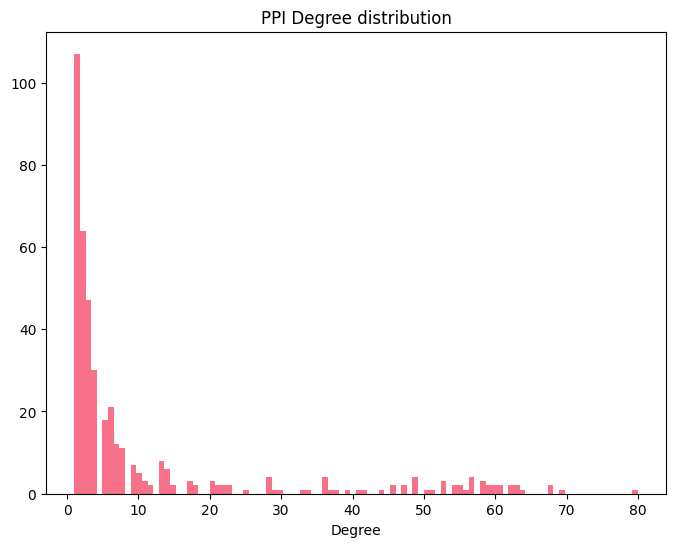

In [33]:
# Analyze the network
p4c.analyze_network()

# Get degree data
degree_data = p4c.get_table_columns(columns=['Degree'])
degrees = degree_data['Degree']

# Plot histogram for display
plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=100)
plt.title("PPI Degree distribution")
plt.xlabel("Degree")
plt.show()

❓ **Question**: Degree distribution

* What are node degree and node betweenness? Describe in your own words.
    - Node degree is the amount of incoming edges to a certain node. Node betweeness is how often a node finds itself on the shortest path between the two nodes.
* Look at the node degree distribution. Is this as expected?
    - Yes, there are a few with high degree, connecting to individual ones.
* Is this a scale-free topology?
    - Yes, exponential distribution of node degrees.

## Network visualization for centrality measures

Let's create a visualization based on the node degree (node color) and betweenness (node size).

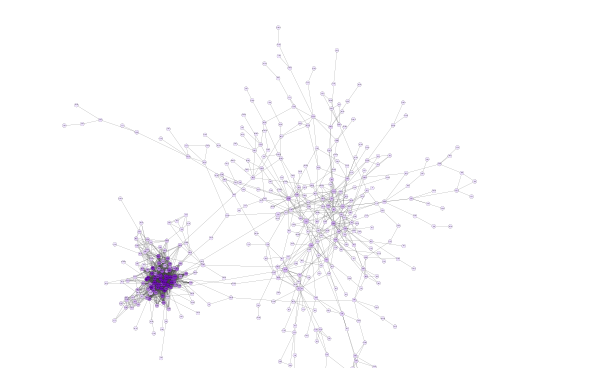

In [34]:
# Create visual style
p4c.create_visual_style("centrality")

# Set node label mapping
p4c.set_node_label_mapping("display name", style_name="centrality")

# Set node color mapping
control_points = [0, 60]
colors = ['#F0E6FF', '#6A0DAD']
p4c.set_node_color_mapping("Degree",
                          table_column_values=control_points,
                          colors=colors,
                          style_name="centrality",
                          default_color="#C0C0C0")

# Set node size mapping
p4c.set_node_size_mapping("BetweennessCentrality",
                         table_column_values=[0, 0.5],
                         sizes=[50, 100],
                         mapping_type="c",
                         style_name="centrality",
                         default_size=10)

# Apply the visual style
p4c.set_visual_style("centrality")

# Toggle graphics details
p4c.toggle_graphics_details()

p4c.notebook_export_show_image()


❓ **Question**: Important notes

Now the node degree is indicated by the size of the nodes and the color shows high betweenness nodes.
* What observations can you make?
    - The left part of the network is smaller and way more interconnected.
* Where are the hub nodes located in the network? (Go to Cytoscape and check them out)
    - On thhe left side.

## Network visualization for gene expression data

What if you want to know if certain genes are up- or down-regulated?

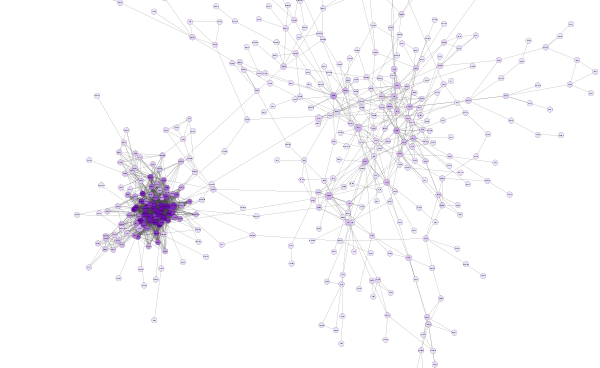

In [35]:
# Load table data
p4c.load_table_data(data=data,
                    data_key_column="GeneID",
                    table="node",
                    table_key_column="query term")

# Create visual style
p4c.create_visual_style("log2FC vis")

# Set node label mapping
p4c.set_node_label_mapping("display name", style_name="log2FC vis")

# Set node color mapping with control points
control_points = [-3.0, 0.0, 3.0]
colors = ['#5588DD', '#FFFFFF', '#DD8855']
p4c.set_node_color_mapping("log2FC",
                          table_column_values=control_points,
                          colors=colors,
                          style_name="log2FC vis",
                          default_color="#C0C0C0")

# Apply the visual style
p4c.set_visual_style("log2FC vis")

# Lock node dimensions
p4c.lock_node_dimensions(True, style_name="log2FC vis")

p4c.notebook_export_show_image()

# Export image (assuming you want to save in the same directory as script)
#p4c.export_image('PPI-with-data.png', type='PNG', zoom=500)

<img src="genes3.png" alt="My Chart" width="600">